In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
import pickle
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge

# Add src to path
sys.path.append(str(Path('..').resolve()))

from src.utils.paths import PROCESSED_DIR, RESULTS_DIR, setup_plotting, ensure_dirs
from src.data.preprocessing import prepare_data

setup_plotting()
ensure_dirs()

In [2]:
# Load datasets
dataset_A = pd.read_csv(PROCESSED_DIR / 'dataset_A_full.csv')
dataset_B = pd.read_csv(PROCESSED_DIR / 'dataset_B_metabolomics.csv')
dataset_C = pd.read_csv(PROCESSED_DIR / 'dataset_C_transcriptomics.csv')

# Find intersection
p_A = set(dataset_A['participant_id'])
p_B = set(dataset_B['participant_id'])
p_C = set(dataset_C['participant_id'])

intersection = sorted(list(p_B & p_C))

print(f"Intersection size: {len(intersection)} participants")

# Filter datasets to intersection and sort by participant_id to ensure alignment
df_B = dataset_B[dataset_B['participant_id'].isin(intersection)].sort_values('participant_id').reset_index(drop=True)
df_C = dataset_C[dataset_C['participant_id'].isin(intersection)].sort_values('participant_id').reset_index(drop=True)

# Prepare features and targets
X_B, y_B, feat_B = prepare_data(df_B, "Modality B (Met+Anthro)")
X_C, y_C, feat_C = prepare_data(df_C, "Modality C (Trans+Anthro)")

# Verify targets are identical
assert np.allclose(y_B, y_C)
y_target = y_B

Intersection size: 30 participants

Modality B (Met+Anthro): 30 samples, 199 features

Modality C (Trans+Anthro): 30 samples, 205 features


In [3]:
def train_late_fusion(X_list, y, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    n_modalities = len(X_list)
    n_samples = len(y)
    
    # Store out-of-fold predictions for each modality
    oof_preds = np.zeros((n_samples, n_modalities))
    y_true = np.zeros(n_samples)
    
    cb_params = {
        'iterations': 1000,
        'depth': 3,
        'learning_rate': 0.05,
        'loss_function': 'RMSE',
        'verbose': False,
        'thread_count': -1,
        'allow_writing_files': False
    }
    
    indices_order = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(y)):
        y_true[test_idx] = y[test_idx]
        indices_order.extend(test_idx)
        
        for m_idx in range(n_modalities):
            X = X_list[m_idx]
            X_train, X_test = X[train_idx], X[test_idx]
            y_train = y[train_idx]
            
            # Train
            cb = CatBoostRegressor(**cb_params, random_seed=random_state + fold_idx)
            cb.fit(X_train, y_train)
            
            # Predict
            oof_preds[test_idx, m_idx] = cb.predict(X_test)
            
    return oof_preds, y_true

In [4]:
# Run CV to get OOF predictions for each modality
X_list = [X_B, X_C]
oof_preds, y_true = train_late_fusion(X_list, y_target)

# 1. Simple Averaging
y_pred_avg = np.mean(oof_preds, axis=1)

# 2. Weighted Averaging (Meta-learner / Stacking with CatBoost)
from sklearn.model_selection import cross_val_predict
kf_stack = KFold(n_splits=5, shuffle=True, random_state=42)
cb_params = {
    'iterations': 1000,
    'depth': 3,
    'learning_rate': 0.05,
    'loss_function': 'RMSE',
    'verbose': False,
    'thread_count': -1,
    'allow_writing_files': False
}
stacker_cb = CatBoostRegressor(**cb_params)
y_pred_stacked_cb = cross_val_predict(stacker_cb, oof_preds, y_true, cv=kf_stack)

# 3. Ridge Stacking (Better for small N)
from sklearn.linear_model import RidgeCV
stacker_ridge = RidgeCV(alphas=np.logspace(-3, 3, 20))
y_pred_ridge = cross_val_predict(stacker_ridge, oof_preds, y_true, cv=kf_stack)

# 4. Optimal Weighted Blending (Search)
from scipy.optimize import minimize

def objective(weights, oof_preds, y_true):
    weights = np.array(weights)
    preds = np.dot(oof_preds, weights)
    return np.mean((y_true - preds)**2)

res = minimize(objective, x0=[0.5, 0.5], args=(oof_preds, y_true), 
               bounds=[(0, 1), (0, 1)], method='L-BFGS-B')
best_weights = res.x
y_pred_opt = np.dot(oof_preds, best_weights)

print(f"Optimal weights: {best_weights}")

# 5. Hybrid Late Fusion
# Stacking modality predictions with top features from the strongest modality
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV

# Identify top features of Modality C (Transcriptomics) using all data in intersection
cb_c = CatBoostRegressor(**cb_params, random_seed=42)
cb_c.fit(X_C, y_target)
importances = cb_c.get_feature_importance()
top_idx = np.argsort(importances)[-10:]
X_C_top = X_C[:, top_idx]

# Impute top features
imputer = SimpleImputer(strategy='mean')
X_C_top_imputed = imputer.fit_transform(X_C_top)

# Create Hybrid Meta-features: [Pred_B, Pred_C, Top_10_Features_C]
X_meta_hybrid = np.column_stack([oof_preds, X_C_top_imputed])

# Train Hybrid Meta-learner (Ridge is robust for small N)
stacker_hybrid = RidgeCV(alphas=np.logspace(-3, 3, 20))
y_pred_hybrid = cross_val_predict(stacker_hybrid, X_meta_hybrid, y_target, cv=kf_stack)

print("Late Fusion training complete.")

Optimal weights: [0.38009006 1.        ]


Late Fusion training complete.


In [5]:
def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae}

results = []
modalities = ['Modality B (Metabolomics)', 'Modality C (Transcriptomics)']

for i, name in enumerate(modalities):
    m_results = calculate_metrics(y_true, oof_preds[:, i])
    m_results['Model'] = name
    results.append(m_results)

# Add Fused results
avg_results = calculate_metrics(y_true, y_pred_avg)
avg_results['Model'] = 'Late Fusion (Averaging)'
results.append(avg_results)

ridge_results = calculate_metrics(y_true, y_pred_ridge)
ridge_results['Model'] = 'Late Fusion (Ridge Stacking)'
results.append(ridge_results)

opt_results = calculate_metrics(y_true, y_pred_opt)
opt_results['Model'] = f'Late Fusion (Opt Weight: {best_weights[0]:.2f}/{best_weights[1]:.2f})'
results.append(opt_results)

hybrid_results = calculate_metrics(y_true, y_pred_hybrid)
hybrid_results['Model'] = 'Late Fusion (Hybrid Stacking)'
results.append(hybrid_results)

stacked_results = calculate_metrics(y_true, y_pred_stacked_cb)
stacked_results['Model'] = 'Late Fusion (Stacking/CatBoost)'
results.append(stacked_results)

results_df = pd.DataFrame(results)
results_df = results_df[['Model', 'R2', 'RMSE', 'MAE']]

results_df.to_csv(RESULTS_DIR / 'late_fusion_metrics.csv', index=False)

/tmp/ipykernel_582977/1267597348.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2', y='Model', data=results_df, palette='viridis')


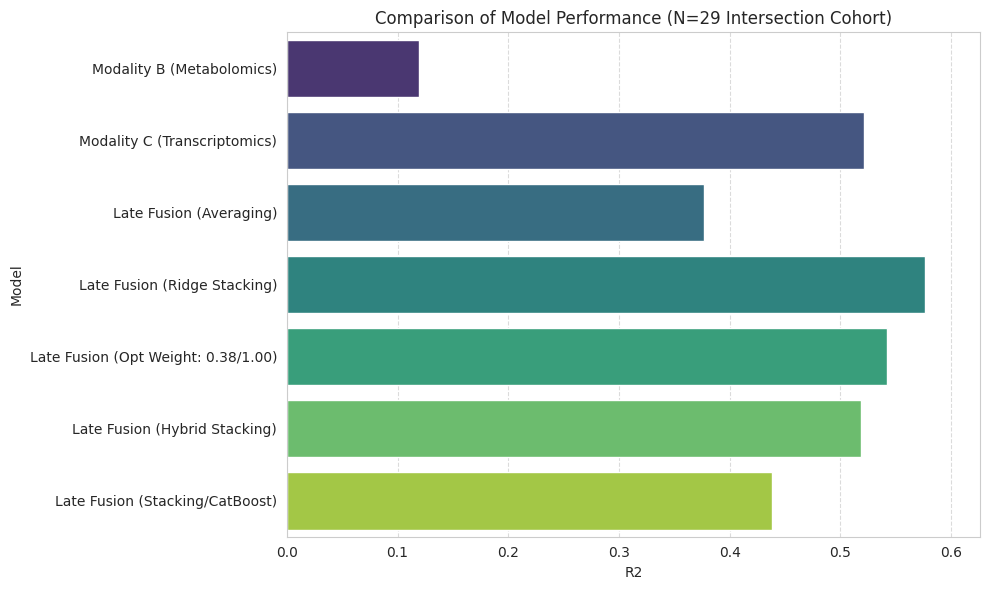

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(x='R2', y='Model', data=results_df, palette='viridis')
plt.title('Comparison of Model Performance (N=29 Intersection Cohort)')
plt.xlim(min(0, results_df['R2'].min() - 0.05), results_df['R2'].max() + 0.05)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'late_fusion_comparison.png')
plt.show()